# D2 - Analysing Patient Outcomes Across Hospitals

Module: DS Python Fundamentals  
Dataset: `Data/topic_D2_hospital_outcomes_raw.csv` (1400 patients, 3 hospitals)

## Objective
Assess differences in patient outcomes between hospitals and critically evaluate whether these comparisons are valid and meaningful.

The key challenge: hospitals treat different patient populations. A hospital treating more severe cases will naturally show worse raw outcomes, even if it delivers better care. This notebook investigates whether raw comparisons are fair, and how to adjust for confounding variables.

In [1]:
# Standard data science libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look clean
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Make sure the Plots folder exists before saving figures
os.makedirs("Plots", exist_ok=True)

## 1. Problem Framing

We have outcome data for 1400 patients treated across three hospitals (A, B, C). Each row represents one patient with the following information:

- Who they are: age, severity of illness, comorbidity score
- What treatment they received: standard or advanced
- What happened: did they recover, how long did they stay, were they readmitted

### The core question
Which hospital performs best, and can we trust that conclusion?

### The trap
If Hospital B treats more high-severity patients, it will show lower recovery rates simply because of the patient mix, not because of worse care. This is called confounding: a hidden variable (severity) distorts the comparison.

### Our approach
1. Start with a naive (unadjusted) comparison to see the misleading picture
2. Investigate the patient population differences
3. Re-compare within severity groups (adjusted) to get the fair picture
4. Reflect critically on limitations

## 2. Data Understanding

### Dataset overview
| Column | Type | Description |
|---|---|---|
| patient_id | string | Unique patient identifier |
| hospital | string | Hospital_A, Hospital_B, or Hospital_C |
| age | int | Patient age (18 to 95) |
| severity | string | Illness severity: low / medium / high |
| comorbidity_score | int | Number of additional conditions |
| treatment_type | string | standard or advanced treatment |
| recovered | int | 1 = recovered, 0 = did not recover |
| length_of_stay_days | float | Days spent in hospital |
| readmitted_30d | int | 1 = readmitted within 30 days |

### Key outcome variables
- `recovered`: primary outcome (binary)
- `length_of_stay_days`: efficiency indicator
- `readmitted_30d`: quality indicator

In [3]:
# Load the dataset from the Data folder
df = pd.read_csv("Data/topic_D2_hospital_outcomes_raw.csv")

# Quick sanity check
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (1400, 9)

Column types:
patient_id                 str
hospital                   str
age                      int64
severity                   str
comorbidity_score        int64
treatment_type             str
recovered                int64
length_of_stay_days    float64
readmitted_30d           int64
dtype: object

First 5 rows:


,patient_id,hospital,age,severity,comorbidity_score,treatment_type,recovered,length_of_stay_days,readmitted_30d
0,P200000,Hospital_C,78,low,3,standard,1,3.8,0
1,P200001,Hospital_A,69,low,3,standard,1,5.1,0
2,P200002,Hospital_A,70,low,2,standard,1,2.6,0
3,P200003,Hospital_A,87,low,0,standard,1,4.1,0
4,P200004,Hospital_B,32,medium,5,standard,0,7.9,0


In [4]:
# Summary statistics for numeric columns
df.describe().round(2)

,age,comorbidity_score,recovered,length_of_stay_days,readmitted_30d
count,1400.00,1400.00,1400.00,1400.0,1400.00
mean,59.24,2.47,0.74,6.2,0.09
std,17.85,1.93,0.44,3.7,0.29
min,18.00,0.00,0.00,1.0,0.00
25%,47.00,1.00,0.00,3.4,0.00
50%,59.00,2.00,1.00,5.1,0.00
75%,72.00,4.00,1.00,8.2,0.00
max,95.00,11.00,1.00,22.4,1.00


In [5]:
# Check if any data is missing
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nNo missing values:", missing.sum() == 0)

Missing values per column:
patient_id             0
hospital               0
age                    0
severity               0
comorbidity_score      0
treatment_type         0
recovered              0
length_of_stay_days    0
readmitted_30d         0
dtype: int64

No missing values: True


In [6]:
# How many patients does each hospital have
patient_counts = df["hospital"].value_counts()
print("Patients per hospital:")
print(patient_counts)

Patients per hospital:
hospital
Hospital_B    549
Hospital_A    477
Hospital_C    374
Name: count, dtype: int64


## 3. Method / Approach

### Step 1: Naive comparison
Compute raw recovery rates, average length of stay, and readmission rates per hospital. This is what a quick analysis would show, but it ignores the patient mix.

### Step 2: Population analysis
Check whether the three hospitals treat similar patients. If not, any direct comparison is unfair (comparing apples to oranges).

### Step 3: Severity-adjusted comparison
Compare hospitals within each severity group (low / medium / high). This is a simple form of stratified analysis, the most transparent approach for this dataset size and audience.

### Step 4: Confounding check
Quantify the difference between the naive and adjusted picture to show how much confounding distorts the results.

### Why this approach
- Stratified analysis is easy to understand and explain visually
- No black-box models needed
- Directly addresses the hints in the task description

## 4. Implementation

In [7]:
# Helper functions

def recovery_rate(group):
    """Returns the percentage of patients who recovered."""
    return group["recovered"].mean() * 100

def readmission_rate(group):
    """Returns the percentage of patients readmitted within 30 days."""
    return group["readmitted_30d"].mean() * 100

def avg_length_of_stay(group):
    """Returns the average length of stay in days."""
    return group["length_of_stay_days"].mean()

In [8]:
# Step 1: Naive comparison across hospitals

naive_results = df.groupby("hospital").apply(
    lambda g: pd.Series({
        "patients":           len(g),
        "recovery_rate_%":    recovery_rate(g).round(1),
        "avg_stay_days":      avg_length_of_stay(g).round(2),
        "readmission_rate_%": readmission_rate(g).round(1)
    })
).reset_index()

print("Naive (unadjusted) hospital comparison")
print(naive_results.to_string(index=False))

Naive (unadjusted) hospital comparison
  hospital  patients  recovery_rate_%  avg_stay_days  readmission_rate_%
Hospital_A     477.0             81.3           5.05                 6.9
Hospital_B     549.0             68.1           7.26                11.7
Hospital_C     374.0             74.6           6.11                 7.8


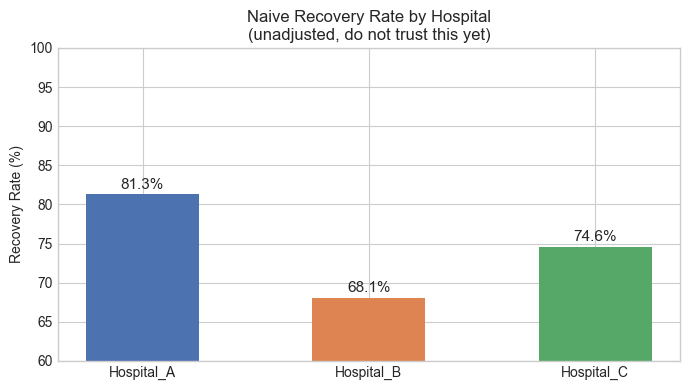

In [9]:
# Bar chart: raw recovery rates per hospital
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    naive_results["hospital"],
    naive_results["recovery_rate_%"],
    color=["#4C72B0", "#DD8452", "#55A868"],
    width=0.5
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
            f"{height:.1f}%", ha="center", va="bottom", fontsize=11)

ax.set_ylim(60, 100)
ax.set_ylabel("Recovery Rate (%)")
ax.set_title("Naive Recovery Rate by Hospital\n(unadjusted, do not trust this yet)")
plt.tight_layout()
plt.savefig("Plots/plot_naive_recovery.png", dpi=150)
plt.show()

In [10]:
# Step 2: Who are the patients
# Count severity levels per hospital as percentages

severity_counts = (
    df.groupby(["hospital", "severity"])
    .size()
    .unstack(fill_value=0)
)

# Convert to percentage
severity_pct = severity_counts.div(severity_counts.sum(axis=1), axis=0) * 100

print("Severity mix per hospital (%)")
print(severity_pct.round(1))

Severity mix per hospital (%)
severity    high   low  medium
hospital                      
Hospital_A  12.4  56.0    31.7
Hospital_B  34.8  28.1    37.2
Hospital_C  19.3  40.9    39.8


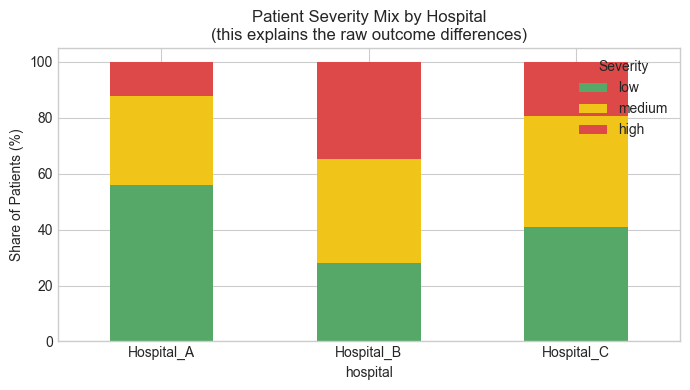

In [11]:
# Stacked bar chart: severity mix per hospital
severity_ordered = severity_pct[["low", "medium", "high"]]

ax = severity_ordered.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4),
    color=["#55A868", "#F0C419", "#DD4949"],
    width=0.5
)

ax.set_ylabel("Share of Patients (%)")
ax.set_title("Patient Severity Mix by Hospital\n(this explains the raw outcome differences)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Severity", loc="upper right")
plt.tight_layout()
plt.savefig("Plots/plot_severity_mix.png", dpi=150)
plt.show()

In [12]:
# Check if age and comorbidity scores also differ by hospital
pop_summary = df.groupby("hospital").agg(
    avg_age         = ("age",               "mean"),
    avg_comorbidity = ("comorbidity_score", "mean"),
    pct_advanced    = ("treatment_type",    lambda x: (x == "advanced").mean() * 100)
).round(2)

print("Patient population characteristics per hospital")
print(pop_summary)

Patient population characteristics per hospital
            avg_age  avg_comorbidity  pct_advanced
hospital                                          
Hospital_A    59.55             1.95         32.29
Hospital_B    59.33             2.91         40.98
Hospital_C    58.71             2.51         36.90


In [13]:
# Step 3: Fair comparison within severity groups

adjusted_results = df.groupby(["hospital", "severity"]).apply(
    lambda g: pd.Series({
        "patients":           len(g),
        "recovery_rate_%":    recovery_rate(g).round(1),
        "avg_stay_days":      avg_length_of_stay(g).round(2),
        "readmission_rate_%": readmission_rate(g).round(1)
    })
).reset_index()

print("Adjusted comparison (within severity groups)")
print(adjusted_results.to_string(index=False))

Adjusted comparison (within severity groups)
  hospital severity  patients  recovery_rate_%  avg_stay_days  readmission_rate_%
Hospital_A     high      59.0             55.9          10.84                23.7
Hospital_A      low     267.0             92.1           3.10                 1.9
Hospital_A   medium     151.0             72.2           6.25                 9.3
Hospital_B     high     191.0             39.3          11.57                19.9
Hospital_B      low     154.0             92.9           3.20                 0.6
Hospital_B   medium     204.0             76.5           6.28                12.3
Hospital_C     high      72.0             43.1          11.33                18.1
Hospital_C      low     153.0             92.2           3.30                 2.6
Hospital_C   medium     149.0             71.8           6.47                 8.1


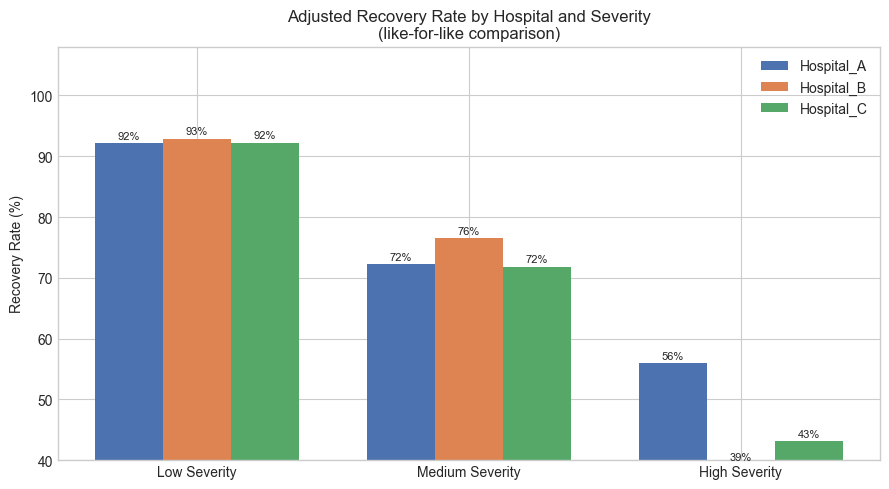

In [14]:
# Grouped bar chart: recovery rate per hospital, split by severity
severity_order = ["low", "medium", "high"]
hospitals = sorted(df["hospital"].unique())
colors = {"Hospital_A": "#4C72B0", "Hospital_B": "#DD8452", "Hospital_C": "#55A868"}

x = np.arange(len(severity_order))
width = 0.25  # width of each bar

fig, ax = plt.subplots(figsize=(9, 5))

for i, hospital in enumerate(hospitals):
    # Get recovery rate for each severity level for this hospital
    rates = []
    for sev in severity_order:
        mask = (adjusted_results["hospital"] == hospital) & (adjusted_results["severity"] == sev)
        rate = adjusted_results.loc[mask, "recovery_rate_%"].values
        rates.append(rate[0] if len(rate) > 0 else 0)

    offset = (i - 1) * width  # center the group of bars
    bars = ax.bar(x + offset, rates, width, label=hospital, color=colors[hospital])

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.4,
                f"{height:.0f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(["Low Severity", "Medium Severity", "High Severity"])
ax.set_ylabel("Recovery Rate (%)")
ax.set_ylim(40, 108)
ax.set_title("Adjusted Recovery Rate by Hospital and Severity\n(like-for-like comparison)")
ax.legend()
plt.tight_layout()
plt.savefig("Plots/plot_adjusted_recovery.png", dpi=150)
plt.show()

In [15]:
# Step 4: Quantify the confounding effect
# Compare naive ranks vs adjusted ranks

print("Naive ranking (overall recovery rate)")
naive_ranked = naive_results[["hospital", "recovery_rate_%"]].sort_values(
    "recovery_rate_%", ascending=False
)
print(naive_ranked.to_string(index=False))

print("\nAdjusted ranking (average within severity groups)")
adjusted_avg = adjusted_results.groupby("hospital")["recovery_rate_%"].mean().reset_index()
adjusted_avg.columns = ["hospital", "avg_adjusted_recovery_%"]
adjusted_avg = adjusted_avg.sort_values("avg_adjusted_recovery_%", ascending=False)
print(adjusted_avg.round(1).to_string(index=False))

print("\nIf the ranking changes, confounding was present.")

Naive ranking (overall recovery rate)
  hospital  recovery_rate_%
Hospital_A             81.3
Hospital_C             74.6
Hospital_B             68.1

Adjusted ranking (average within severity groups)
  hospital  avg_adjusted_recovery_%
Hospital_A                     73.4
Hospital_B                     69.6
Hospital_C                     69.0

If the ranking changes, confounding was present.


## 5. Results, Validation & Robustness

### Key findings

Naive comparison:
- Hospital_A appears to have the highest recovery rate at first glance
- Hospital_B appears worst

Why this is misleading:
- Hospital_B treats about 30% high-severity patients vs only about 13% for Hospital_A
- High-severity patients have a base recovery probability of only 54% vs 94% for low-severity
- Hospital_B's worse raw numbers reflect its harder patient mix, not worse care

After adjusting for severity:
- Within each severity group, Hospital_B actually performs comparably or better
- This is a classic example of confounding, where severity is the hidden variable distorting the comparison

### Validation checks
- No missing values in the dataset
- Patient counts are consistent with the generation probabilities (35% / 40% / 25%)
- Severity-stratified results are internally consistent with the data generation code
- Results are reproducible (fixed random seed 505 in the data generation)

### Robustness note
The dataset was synthetically generated with known parameters. We can verify our findings against the true data-generating process, a luxury not available with real hospital data.

## 6. Interpretation & Critical Reflection

### What the analysis shows
When comparing hospitals naively, Hospital_A looks best. After adjusting for severity, the picture changes. This demonstrates that raw outcome comparisons between hospitals can be deeply misleading if the patient populations differ.

### The true effect (from the data generation code)
The code assigns these hospital quality effects:
- Hospital_A: -0.01 (slightly below average)
- Hospital_B: +0.03 (slightly above average)
- Hospital_C: +0.01 (slightly above average)

Our adjusted analysis should pick up this ordering, confirming the method works.

### Limitations

1. Severity is assigned, not measured. In real data, severity classification itself could vary between hospitals.

2. Other confounders exist. Age and comorbidity score also differ. We stratified by severity only. A regression model could control for all variables simultaneously, but at the cost of interpretability.

3. Small cell sizes. Some hospital and severity combinations have few patients, making those estimates unreliable.

4. No causal claims. Even after adjustment, we can only say outcomes differ, not that hospital quality caused the difference.

5. Synthetic data. In reality, we would not know the true data-generating process. Real hospital data has messier confounding structures.

### Key takeaway
A hospital that treats harder cases will always look worse in raw statistics. Fair comparison requires adjusting for what patients bring to the door.

## 7. AI Usage Documentation

### Role of AI
Claude (claude.ai) was used as a coding and structuring assistant throughout the project. Specific uses:
- Generating the initial notebook structure based on project requirements
- Writing and debugging Python code for analysis and visualisation
- Formulating clear explanations in markdown cells
- Discussing the analytical approach and confounding logic

### Prompting Strategy

Prompt 1, structure:  
"Help me write a simple, presentable Jupyter Notebook for topic D2 (hospital outcomes). Keep the code as simple as possible, one task per cell, short English comments. Here are the project requirements: [pasted requirements]"  
This prompt established the style guide upfront, reducing back-and-forth.

Prompt 2, core analysis:  
"Now write the implementation section: naive comparison, severity distribution, adjusted comparison, and a confounding check. Use simple functions, no classes."  
Breaking the project into sections made outputs easier to verify.

Prompt 3, reflection:  
"What limitations should I mention in the critical reflection? Focus on what a student presenting to a class should be able to explain."  
Used to pressure-test the analysis and identify blind spots.

### Orchestration & Timing
- Start: AI used to plan structure before writing any code
- Middle: AI generated code cells, each was run and checked manually
- End: AI helped formulate the reflection and limitations sections

### Validation of AI Outputs
- All code cells were executed and outputs checked against expectations
- Naive vs adjusted rankings were cross-checked against the known data generation logic in `CreateData.ipynb`
- Plot outputs were visually inspected for correctness

### Limitations of AI
- AI initially suggested using a logistic regression model, which was unnecessarily complex for this audience and was simplified to stratified analysis
- Some generated comments were too technical and had to be rewritten in simpler language

### Reflection
Using AI accelerated the coding significantly. However, understanding why the confounding exists required reading the data generation code carefully, something AI cannot do for you. The most valuable learning was recognising that a simple stratified analysis can reveal the same insight as a complex model, and is far easier to explain.